In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load the data
df = pd.read_csv('/content/sample_data/netflix.csv')

df.head(5)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Basic Metric Analysis

In [ ]:
df.shape

(8807, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
#Convert Datatypes

df["type"] = df["type"].astype("category")

df["rating"] = df["rating"].astype("category")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       8807 non-null   object  
 1   type          8807 non-null   category
 2   title         8807 non-null   object  
 3   director      6173 non-null   object  
 4   cast          7982 non-null   object  
 5   country       7976 non-null   object  
 6   date_added    8797 non-null   object  
 7   release_year  8807 non-null   int64   
 8   rating        8803 non-null   category
 9   duration      8804 non-null   object  
 10  listed_in     8807 non-null   object  
 11  description   8807 non-null   object  
dtypes: category(2), int64(1), object(9)
memory usage: 706.2+ KB


In [ ]:
#statistical analysis
print("\nStatistical Summary (Continuous Variables):")
print(df.describe())

print("\nStatistical Summary (Categorical Variables):")
print(df.describe(include=['object', 'category']))




Statistical Summary (Continuous Variables):
                          date_added  release_year
count                           8797   8807.000000
mean   2019-05-17 05:59:08.436967168   2014.180198
min              2008-01-01 00:00:00   1925.000000
25%              2018-04-06 00:00:00   2013.000000
50%              2019-07-02 00:00:00   2017.000000
75%              2020-08-19 00:00:00   2019.000000
max              2021-09-25 00:00:00   2021.000000
std                              NaN      8.819312

Statistical Summary (Categorical Variables):
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   

              country rating  duration                     listed_in  \
count            7976   8803      880

In [ ]:
#missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
#duplicate records
df.duplicated().sum()

np.int64(0)

Shape of the Data

The dataset has 8,807 rows and 12 columns. Each row represents one Movie or TV Show available on Netflix, and each column contains information such as the title, director, cast, country, release year, rating, duration, genre, and description.

Data Types

Most of the columns contain text values, so they are stored as the object data type. The release_year column contains numbers and is stored as an integer (int64). The date_added column is stored as text and needs to be converted to datetime for date-based analysis.

Conversion of Categorical Attributes

Some columns have only a few repeated values, so they can be converted to the category data type.

type was converted to category because it contains only Movie and TV Show.
rating was converted to category because it has a fixed number of rating values.

Missing Value Detection

Some columns have missing values.

Director has the highest number of missing values (2,634).
Country has 831 missing values.
Cast has 825 missing values.
A few missing values are also present in date_added (10), rating (4), and duration (3).
Other columns do not have missing values.

Statistical Summary (Numerical)

The release_year ranges from 1925 to 2021.
The average release year is around 2014, while the middle value (median) is 2017. This shows that most of the content available on Netflix is from recent years.

Statistical Summary (Categorical)

Netflix has more Movies (6,131) than TV Shows (2,676). The most common rating is TV-MA, which means Netflix has a large amount of content for mature audiences. The United States has the highest number of titles (2,818). For TV Shows, "1 Season" is the most common duration, showing that many TV Shows on Netflix have only one season.



 # Non-Graphical Analysis: Value counts and unique attributes





In [ ]:
# Type count
print(df['type'].value_counts())

# Rating count
print(df['rating'].unique())

# Top countries
print(df['country'].value_counts().head())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', ..., '66 min', 'NR', NaN, 'TV-Y7-FV', 'UR']
Length: 18
Categories (17, object): ['66 min', '74 min', '84 min', 'G', ..., 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64


#Data pre-processing : Because cast, directors, listed_in (genres), and countries can have multiple values separated by commas, unnesting is necessary for analysis.

In [ ]:
# Unnesting required columns
def unnest(df, col):
    subset = df[['show_id', 'type', 'title', col]].copy()
    subset[col] = subset[col].str.split(', ')
    return subset.explode(col).dropna()

df_country = unnest(df, 'country')
df_genre   = unnest(df, 'listed_in')
df_cast    = unnest(df, 'cast')
df_director = unnest(df, 'director')

df_cast     = df_cast[df_cast['cast'] != 'Unknown']
df_director = df_director[df_director['director'] != 'Unknown']

#Analysis of basic questions listed in the task

*   Movies heavily dominate the Netflix platform. Out of the entire catalog, roughly 70% are Movies, while 30% are TV Shows.

*   From 1990 to roughly 2012, movie releases grew at a very slow, steady pace. However, starting in 2013, there was a massive, exponential spike in movies being released, peaking in 2017 and 2018 (with 767 movies released in each of those years). The numbers dipped in 2020 and 2021, primarily due to the COVID-19 pandemic shutting down global productions.

*   The data shows that the best time to launch a TV show is during the winter and summer holidays. December is the top month for launching TV shows (266 shows added), closely followed by July (262 shows), September (251 shows), and August (236 shows). Netflix capitalizes on times when schools are closed and people have time off work to binge-watch.

*   Content availability varies drastically by region:

United States: The massive global leader, producing almost 3x more movies (2,751) than TV shows (938).

India: Heavily favors Movies over TV shows. They have 962 movies available but only 84 TV shows.

Japan & South Korea: These are the rare exceptions to the rule! Both countries actually produce more TV Shows than Movies on Netflix, heavily driven by the massive popularity of Anime (Japan) and K-Dramas (South Korea).

*   Analysis of Actors / Directors
Actors (Movies): The top movie actors globally are all from India (Anupam Kher, Shah Rukh Khan, Naseeruddin Shah). This indicates Netflix has heavily licensed massive Bollywood catalogs.

Actors (TV Shows): The top TV actors are predominantly Japanese voice actors (Takahiro Sakurai, Yuki Kaji, Ai kayano), highlighting just how many Anime series Netflix has acquired or produced.

Directors: The most frequent director on the platform is Rajiv Chilaka (creator of the Indian animated series Chhota Bheem), followed by Jan Suter and Raúl Campos (who co-direct a massive amount of stand-up comedy specials).

*  While Netflix still adds more absolute numbers of Movies than TV Shows every year, the growth rate of TV Shows is much faster. For example, in 2015, Netflix added more than twice as many movies (56) as TV shows (26). By 2021, the gap had closed significantly (993 movies vs 505 TV shows). Netflix is definitely shifting its budget to focus more heavily on multi-episode TV shows to keep users subscribed longer.



<Axes: xlabel='type', ylabel='count'>

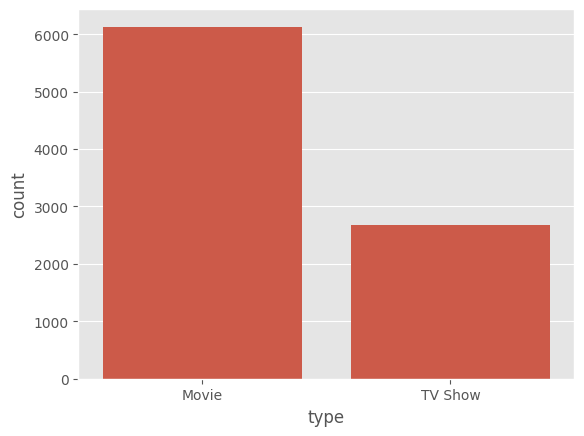

In [ ]:
# movie vs tv show
sns.countplot(x="type", data=df)

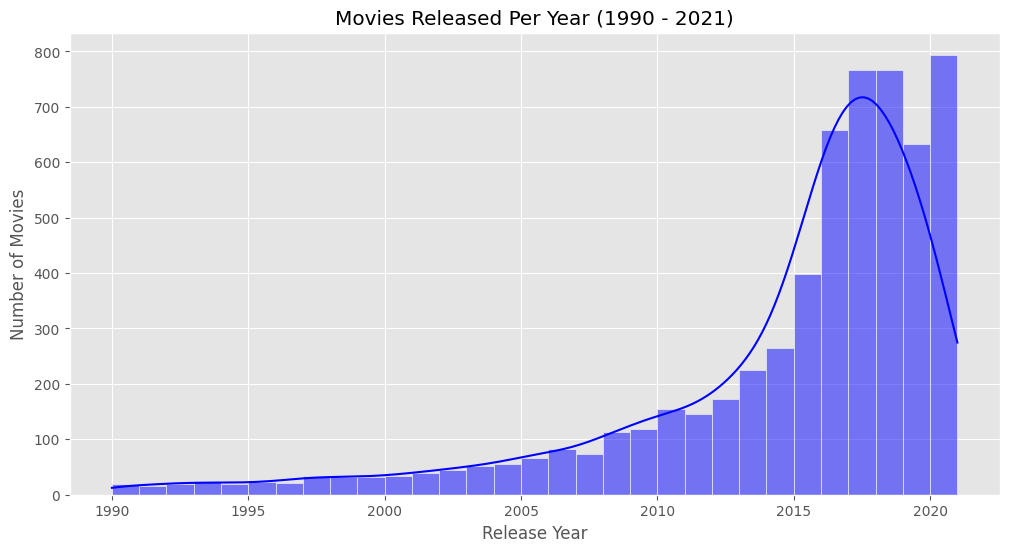

In [ ]:
# movies released over last 20-30 years
movies_df = df[df['type'] == 'Movie']
movies_last_30 = movies_df[movies_df['release_year'] >= 1990]

plt.figure(figsize=(12,6))
sns.histplot(movies_last_30['release_year'], bins=31, kde=True, color='blue')
plt.title('Movies Released Per Year (1990 - 2021)')
plt.ylabel('Number of Movies')
plt.xlabel('Release Year')
plt.show()

In [ ]:
# best time to launch a tv show
tv_shows = df[df['type'] == 'TV Show']
tv_shows['added_month_name'] = tv_shows['date_added'].dt.month_name()

print(tv_shows['added_month_name'].value_counts().head(12))

added_month_name
December     266
July         262
September    251
August       236
June         236
October      215
April        214
March        213
November     207
May          193
January      192
February     181
Name: count, dtype: int64


In [ ]:
# type of content available in different countries
country_content = df_country.groupby(['country', 'type']).size().unstack().fillna(0)
country_content['Total'] = country_content['Movie'] + country_content['TV Show']
print(country_content.sort_values('Total', ascending=False).head(10))

type            Movie  TV Show  Total
country                              
United States    2751      938   3689
India             962       84   1046
United Kingdom    532      272    804
Canada            319      126    445
France            303       90    393
Japan             119      199    318
Spain             171       61    232
South Korea        61      170    231
Germany           182       44    226
Mexico            111       58    169


In [ ]:
# Assuming df_cast and df_director are unnested and "Unknown" is removed
print("--- Top Movie Actors ---")
print(df_cast[df_cast['type']=='Movie']['cast'].value_counts().head(3))

print("\n--- Top TV Show Actors ---")
print(df_cast[df_cast['type']=='TV Show']['cast'].value_counts().head(3))

print("\n--- Top Movie Directors ---")
print(df_director[df_director['type']=='Movie']['director'].value_counts().head(3))

--- Top Movie Actors ---
cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    32
Name: count, dtype: int64

--- Top TV Show Actors ---
cast
Takahiro Sakurai    25
Yuki Kaji           19
Ai Kayano           17
Name: count, dtype: int64

--- Top Movie Directors ---
director
Rajiv Chilaka    22
Jan Suter        21
Raúl Campos      19
Name: count, dtype: int64


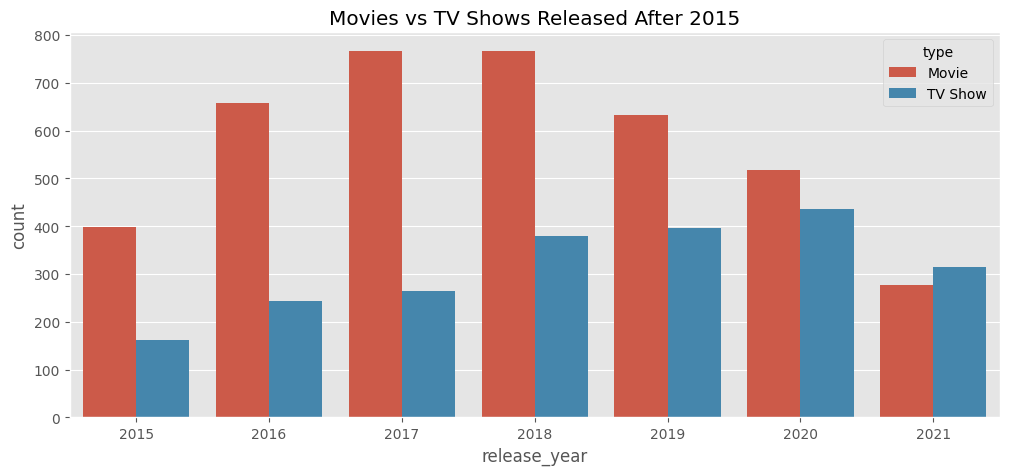

In [ ]:
# Comparing content ADDED to Netflix by year
recent = df[df["release_year"] >= 2015]
plt.figure(figsize=(12,5))

sns.countplot(x="release_year",
              hue="type",
              data=recent)

plt.title("Movies vs TV Shows Released After 2015")
plt.show()

#univariate analysis

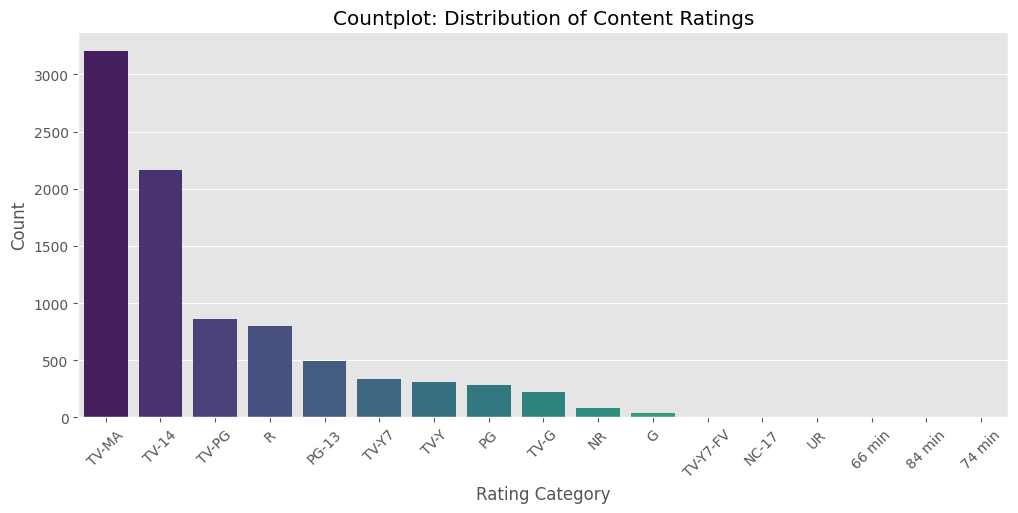

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(x='rating', data=df, palette='viridis',
              order=df['rating'].value_counts().index) # Orders from highest to lowest
plt.title('Countplot: Distribution of Content Ratings')
plt.xlabel('Rating Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

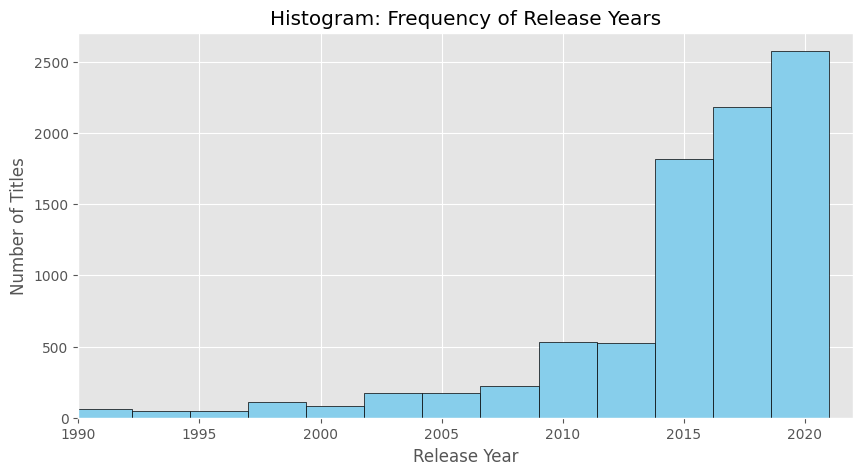

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df['release_year'], bins=40, color='skyblue', edgecolor='black')
plt.title('Histogram: Frequency of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xlim(1990, 2022)
plt.show()

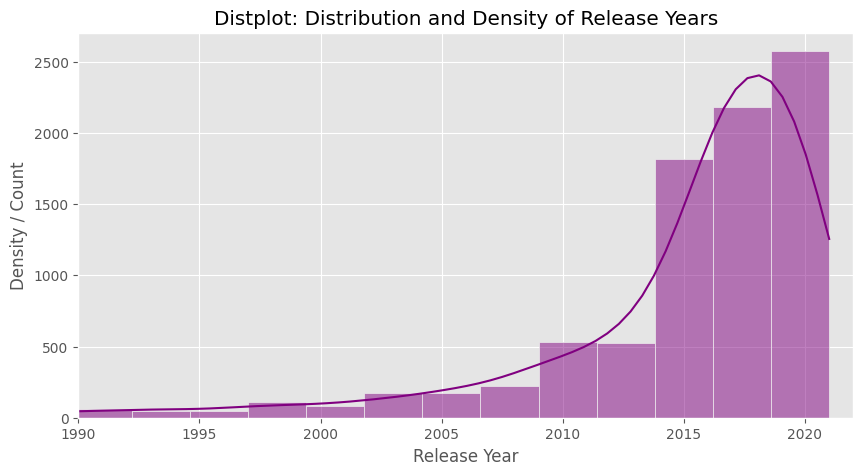

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['release_year'], kde=True, color='purple', bins=40)
plt.title('Distplot: Distribution and Density of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Density / Count')
plt.xlim(1990, 2022)
plt.show()

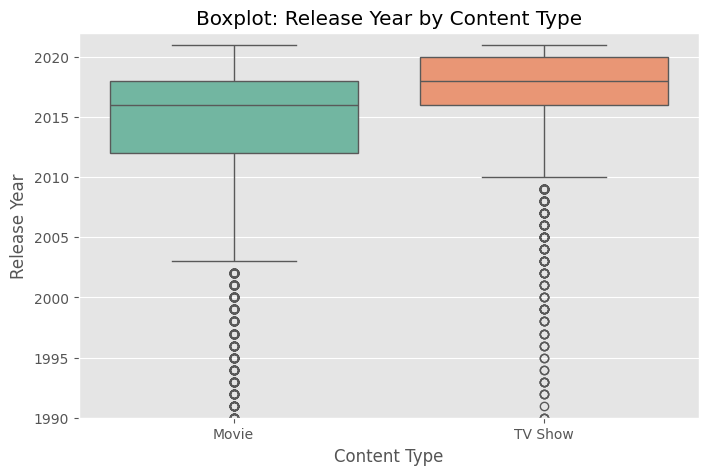

In [ ]:
#bivariate analysis
plt.figure(figsize=(8, 5))

sns.boxplot(x='type', y='release_year', data=df, palette='Set2')


plt.title('Boxplot: Release Year by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Release Year')
plt.ylim(1990, 2022)
plt.show()

In [ ]:
# outlier check for above boxplot
print("Movie Outliers (Released before 2003):", len(df[(df['type']=='Movie') & (df['release_year'] < 2003)]))
print("TV Show Outliers (Released before 2010):", len(df[(df['type']=='TV Show') & (df['release_year'] < 2010)]))

Movie Outliers (Released before 2003): 593
TV Show Outliers (Released before 2010): 182


In [ ]:
#missing value treatment
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
print(df.isnull().sum())


show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
added_year      10
added_month     10
month_added     10
dtype: int64


#Insights based on Non-graphical Analysis
*   Movies are much higher than TV Shows on Netflix platform
*   TV-MA is the most common rating.
*   The United States is the top content producer, followed by India and the UK.

#Insights based on Visual Analysis:-

# Univariate (Continuous)
Countplot (Rating): The Rating countplot shows that TV-MA and TV-14 are by far the most dominant ratings, proving that Netflix's primary target demographic is mature adults and teenagers, rather than young children.

Histogram (Release Year): The histogram bars show a massive concentration of content released between 2015 and 2021. The steep drop-off in 2021 (compared to 2018-2019) visually represents the slowdown in global film/TV production due to the pandemic.

Distplot (Release Year): The KDE (Kernel Density Estimate) line layered over the distplot highlights that the distribution of release_year is highly left-skewed (negatively skewed). The long tail stretches out to the left (older classic movies from the 1900s), but the vast majority of the volume is densely packed on the right side of the graph (modern content).

#Categorical (Boxplot)
Median (The line inside the box): The median release year for TV Shows is slightly higher (more recent) than the median for Movies. This reinforces the finding that Netflix's big push into TV Shows is a more recent phenomenon.

Spread (The size of the box): The box for Movies is taller than the box for TV Shows. This means the middle 50% of movies on Netflix span a wider range of years, whereas the middle 50% of TV shows are tightly packed into very recent years.

Outliers (The dots below the whiskers): Even when zooming in to 1990, you will see dots trailing down below the Movie box. These represent "outliers"—older classic movies that fall far outside the normal concentration of modern content. TV shows have far fewer outliers, showing that Netflix rarely licenses older vintage TV series compared to vintage movies.


#Business Insights


*   Movies still make up the majority of Netflix's catalogue.
*   TV Shows have grown rapidly since 2015.
*   USA and India are the biggest content producers.
*   Most content targets adult audiences (TV-MA).
*   Long-running TV Shows are becoming increasingly important for viewer retention.
*   International Movies and Dramas dominate the platform, heavily fueled by India's massive film output.






# Recommendations


*   Continue investing in original TV Shows because demand has grown in recent years.
*  Produce more regional-language content in India, South Korea, Japan, and other emerging markets.
*   Focus on Drama, Comedy, Thriller, and International genres, as they dominate the catalogue.
*  Increase family-friendly and children's programming to attract a broader audience.
*   Release major titles during peak viewing periods in the second half of the year.
*   Build long-term partnerships with successful directors and actors while supporting new talent.
*  Use country-specific content strategies instead of a one-size-fits-all global approach.
*   Expand multi-season TV series to improve subscriber retention.

  

